# K-Nearest-Neighbors

👇 Load the `houses_clean.csv` dataset located in the `data` folder  
Or you can load it directly from this URL: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

The dataset description can be found in the dataset-description.md file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv')

df.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
0,0.380070,0.375,0.333333,0.500,1,208500
1,-0.312090,0.375,0.333333,0.875,1,181500
2,0.497489,0.375,0.333333,0.500,1,223500
3,0.390885,0.375,0.333333,0.500,1,140000
4,1.134029,0.500,0.333333,0.500,1,250000


💡 Most features have already been pre-processed (scaled with normalization), just like you did on the Data Preparation day  

💡 One feature, `GrLiveArea`, has not been normalized. We keep it this way so we can later see the effect of normalization on our model performance  

👇 You can easily see this with descriptive statistics — look at the min and max values

In [2]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Default KNN

🎯 The task is to predict the price of houses (`SalePrice`) using all features.

👇 Use cross-validation to evaluate a default [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) on this task.  
❓ What proportion of variance in `SalePrice` is explained by the features?  
Store your answer in a variable named `base_knn_score`.

<details>
<summary> 💡 Hint </summary>
    <br>
    ℹ️ The proportion of variance in the dependent variable explained by the independent variables is the R2 score.
</details>

In [3]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate

In [4]:
X = df.drop(columns= ["SalePrice"])
y = df.SalePrice

knn_model = KNeighborsRegressor()

cv_results = cross_validate(knn_model, X,y)

base_knn_score = cv_results['test_score'].mean()
base_knn_score

0.6085640394084016

### 🧪 Check your code

In [5]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Scale Sensitivity

KNNs and distance-based algorithms can be extremely sensitive to the scale of features.

👇 Rescale the feature set to a **full common range** and save it under a variable named `X_rescaled`  
Then, evaluate a model on the rescaled features and save its score under a variable named `rescaled_score`.

<details>
<summary> 💡 Hint </summary>
    
`MinMaxScaler()`

Even though only `GrLiveArea` needs to be normalized, it's fine to use MinMaxScaler on all your features  
    
Indeed, Min-Max Scaling is an [idempotent](https://en.wikipedia.org/wiki/Idempotence) transformation: if $X_{max}=1$ and $X_{min}=0$, then $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

cv_results = cross_validate(knn_model, X_rescaled,y)

rescaled_score = cv_results['test_score'].mean()
rescaled_score

0.6496841000103444

👉 The R2 score should have improved!

💡 When modeling with distance-based algorithms, it is preferred for features to be on a full common range.  
However, it does not always guarantee a better score.  
It is a trial and error process.

### 🧪 Check your code

In [7]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimization

👇 Fine-tune the K parameter (using the `n_neighbors` parameter) of a KNNRegressor on the rescaled features. Plot the evolution of the score as K increases from 1 to 25.

In [8]:
score = []
neighbors = []

for k in range(1, 26):
    knn_model = KNeighborsRegressor(n_neighbors=k)

    cv_results = cross_validate(knn_model, X_rescaled,y)

    score.append(cv_results['test_score'].mean())
    neighbors.append(k)

❓ Which value of K produces the best performance? Store your answer under the variable name `best_k`.

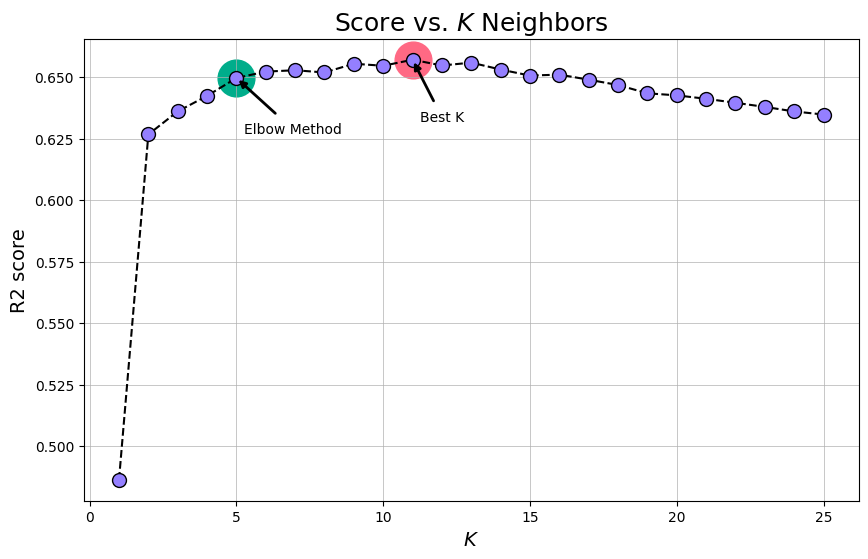

In [15]:
# Plot the evolution of the score below

with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(10,6))
    # getting axes
    ax = plt.gca()
    # plotting
    ax.plot(range(1,26),score,color='black', linestyle='dashed', marker='o',markerfacecolor='#947FFF', markersize=10)
    # more
    ax.set_title('Score vs. $K$ Neighbors', fontsize = 18)
    ax.set_xlabel('$K$', fontsize = 14)
    ax.set_ylabel('R2 score', fontsize = 14)
    ax.grid(axis="x",linewidth=0.5)
    ax.grid(axis="y",linewidth=0.5)
    # best K
    # focusing
    ax.scatter(5,score[5-1],c='#00ad8b',s=700)
    ax.scatter(11,score[11-1],c='#ff6984',s=700)
    
    # annotate
    ax.annotate("Elbow Method", 
                xy=(5,score[5-1]),
                xytext=(5+0.25,score[6-1]-0.025), 
                arrowprops=dict(arrowstyle='-|>',
                                fc="k",
                                ec="k",
                                lw=2),
                bbox=dict(pad=5, facecolor="none", edgecolor="none")
               )
    
    ax.annotate("Best K", 
            xy=(11,score[11-1]),
            xytext=(11+0.25,score[11-1]-0.025), 
            arrowprops=dict(arrowstyle='-|>',
                            fc="k",
                            ec="k",
                            lw=2),
            bbox=dict(pad=5, facecolor="none", edgecolor="none")
           )

    
    plt.show()

In [17]:
best_k = 11

<details>
<summary> 👉 Solution 👈</summary>
    
Looking at your plot, you should see that the score stops increasing around k = 5 and the maximum score is reached for k = 11.

</details>

❓ How do you interpret the poor performance of the model for values of $k$ < 5?

<details>
<summary> 👉 Solution 👈</summary>
    
When K is too small, the model will tend to overfit the training set. It will focus on too few points to generalize well. Increasing K gives the model more examples to base its predictions on.

</details>

### 🧪 Check your code

In [18]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# Overfitting in KNN

💡 When the K parameter of KNNs is too small, there is a risk of overfitting the training set and failing to generalize well.

👇 Plot the learning curves of a KNN with K=2.

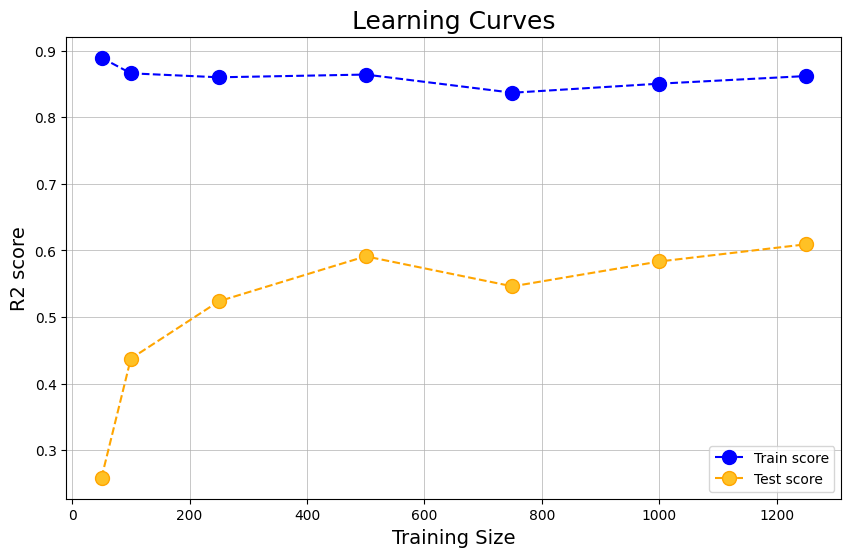

In [23]:
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
import numpy as np

# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(estimator = KNeighborsRegressor(n_neighbors=2), 
                                                        X = X_rescaled, 
                                                        y = y, 
                                                        train_sizes = [50,100,250,500,750,1000,1250], 
                                                        cv = 10,
                                                        scoring = 'r2')

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curves
with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(10,6))
    # getting axes
    ax = plt.gca()
    # plotting
    ax.plot(train_sizes, train_scores_mean, label = 'Train score',color='blue', linestyle='dashed', marker='o',markerfacecolor='blue', markersize=10)
    ax.plot(train_sizes, test_scores_mean, label = 'Test score',color='orange', linestyle='dashed', marker='o',markerfacecolor='#ffc125', markersize=10)
    # more
    ax.set_title('Learning Curves', fontsize = 18)
    ax.set_xlabel('Training Size', fontsize = 14)
    ax.set_ylabel('R2 score', fontsize = 14)
    ax.grid(axis="x",linewidth=0.5)
    ax.grid(axis="y",linewidth=0.5)
    ax.legend(loc="best")

    plt.show()

👉 You should observe a high training score but a low test score. ⚠️ Overfitting warning ⚠️ This is caused by the very low K parameter.

# Ideal K

👇 This time, plot the learning curves for the ideal K value you found in the "$k$ Optimization" section.

In [24]:
# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(estimator = KNeighborsRegressor(n_neighbors=best_k),
                                                              X = X_rescaled, 
                                                              y = y, 
                                                              train_sizes = [50,100,250,500,750,1000,1250], 
                                                              cv = 10,
                                                              scoring = 'r2')
# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

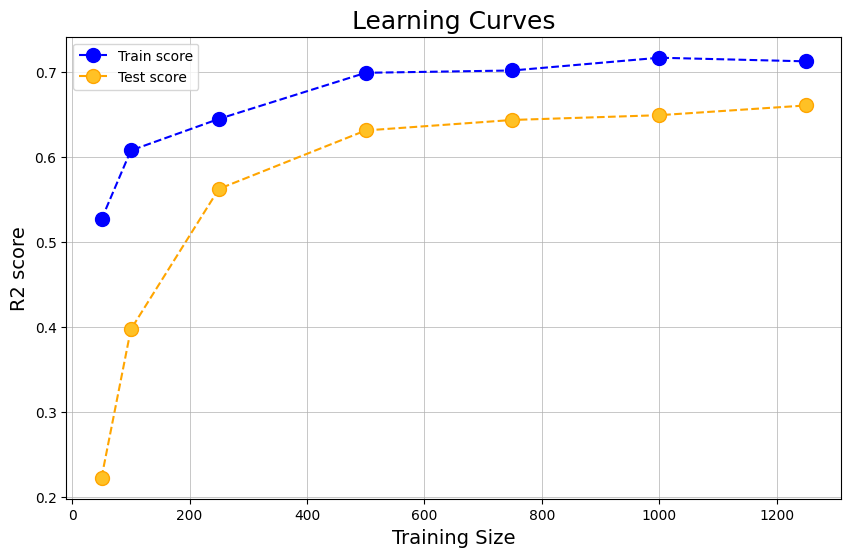

In [25]:
# Plot the learning curves
with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(10,6))

    # getting axes
    ax = plt.gca()

    # plotting
    ax.plot(train_sizes, train_scores_mean, label = 'Train score',color='blue', linestyle='dashed', marker='o',markerfacecolor='blue', markersize=10)
    ax.plot(train_sizes, test_scores_mean, label = 'Test score',color='orange', linestyle='dashed', marker='o',markerfacecolor='#ffc125', markersize=10)

    # more
    ax.set_title('Learning Curves', fontsize = 18)
    ax.set_xlabel('Training Size', fontsize = 14)
    ax.set_ylabel('R2 score', fontsize = 14)
    ax.grid(axis="x",linewidth=0.5)
    ax.grid(axis="y",linewidth=0.5)
    ax.legend(loc="best")

    plt.show()

👉 The curves should be close to converging, indicating that the model overfits less and generalizes better.

💡 There are two key things to remember when modeling with KNN models:  
    1. Distance-based algorithms are extremely sensitive to the scale of features  
    2. K must be tuned: it controls the trade-off between performance, generalization, and overfitting

❓ What is the average difference between the real price and the predicted price for the optimized KNN model? Compute your answer and store it under the variable name `price_error`

<details>
<summary> 💡 Hint </summary>
    
The metric you need to compute is the **Negative Mean Absolute Error (MAE)**.

</details>

In [29]:
cv_results = cross_validate(KNeighborsRegressor(n_neighbors=best_k), X_rescaled,y, scoring='neg_mean_absolute_error')

price_error = cv_results['test_score'].mean()

price_error

-30819.016376089665

### 🧪 Check your code

In [30]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.06s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Selection

❓ Which of these two models would you choose to perform the task of predicting house prices:
- The KNN model you just tuned
- A Linear Regression model

Store your answer as a string under the variable name `best_model`, either "KNN" or "LinearReg".

<details>
<summary> 💡 Hint </summary>
    
To decide which one to choose, you will need to evaluate a Linear Regression score on the same task and compare it with KNN's score. Make sure you are comparing the same metrics!!

</details>

In [34]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

cv_results = cross_validate(linear_model, X_rescaled,y, scoring='neg_mean_absolute_error')

linear_score = cv_results['test_score'].mean()

print(linear_score)

best_model = "KNN"


-33586.16906310636


💡 When comparing the metrics of both models, the KNN model should outperform Linear Regression. This may be due to its ability to capture non-linear patterns in the data.

### 🧪 Check your code

In [35]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁